# DCT Laboratory — Volume I, Chapter 10
## Enterprise Capital Architecture
**Seed `26110`** · Companion to the chapter and AXIOM Module **AXIOM-10**

Capital beyond finance, in motion: three stocks (Financial, Human, Technological)
under the accumulation law $K_{k+1} = (1-\delta)K_k + I_k$, two allocation
policies through a multiplicative productivity function, and the
**accumulation/depletion asymmetry** — destroyed in one quarter, rebuilt in ten.
Mirrored in `DCT_V1_Ch10_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26110
K0    = np.array([40.0, 30.0, 20.0])          # Financial, Human, Technological
DELTA = np.array([0.02, 0.06, 0.10])
ALPHA = np.array([0.30, 0.40, 0.30])
A_TFP, N = 10.0, 20
I_A = np.array([2.0, 2.0, 2.0])               # balanced allocation
I_B = np.array([4.0, 1.0, 1.0])               # finance-heavy allocation

def path(I, n=N, k0=K0, shock=None):
    """shock = (quarter, index, multiplier) applied AFTER accumulation that quarter."""
    ks = np.empty((n+1, 3)); ks[0] = k0
    for k in range(n):
        ks[k+1] = (1-DELTA)*ks[k] + I
        if shock and k+1 == shock[0]:
            ks[k+1, shock[1]] *= shock[2]
    return ks

def output(ks):
    return A_TFP*np.prod(ks**ALPHA, axis=1)

def recovery_quarters():
    base = path(I_A)
    pre = base[10, 1]                          # Human capital before the shock
    sh = path(I_A, shock=(10, 1, 0.7))
    later = sh[11:, 1]
    below = int((later < pre).sum())           # quarters spent below pre-shock level
    return pre, below

def reference_values():
    ka, kb = path(I_A), path(I_B)
    ya, yb = output(ka), output(kb)
    pre, rec = recovery_quarters()
    return {
        "F20_A": round(float(ka[20,0]),4), "H20_A": round(float(ka[20,1]),4),
        "T20_A": round(float(ka[20,2]),4),
        "Y20_A": round(float(ya[20]),4), "Y20_B": round(float(yb[20]),4),
        "cumY_gap_A_minus_B": round(float(ya[1:].sum()-yb[1:].sum()),4),
        "H10_preshock": round(float(pre),4),
        "recovery_quarters": rec,
    }
if __name__ == "__main__":
    [print(f"{k:22s} {v}") for k,v in reference_values().items()]

F20_A                  59.9435
H20_A                  32.3663
T20_A                  20.0
Y20_A                  337.0303
Y20_B                  269.6156
cumY_gap_A_minus_B     800.4275
H10_preshock           31.5379
recovery_quarters      10


## Panel 1 — Two allocations of the same budget
Six units of investment per quarter, split balanced (2,2,2) vs finance-heavy
(4,1,1). Financial capital depreciates slowest — and the finance-heavy policy
still loses: output is multiplicative in the stocks (Capital Productivity
Theorem), so starving the fast-depreciating stocks costs more than stacking the
durable one earns. Cumulative gap over five years: **800 output units**.

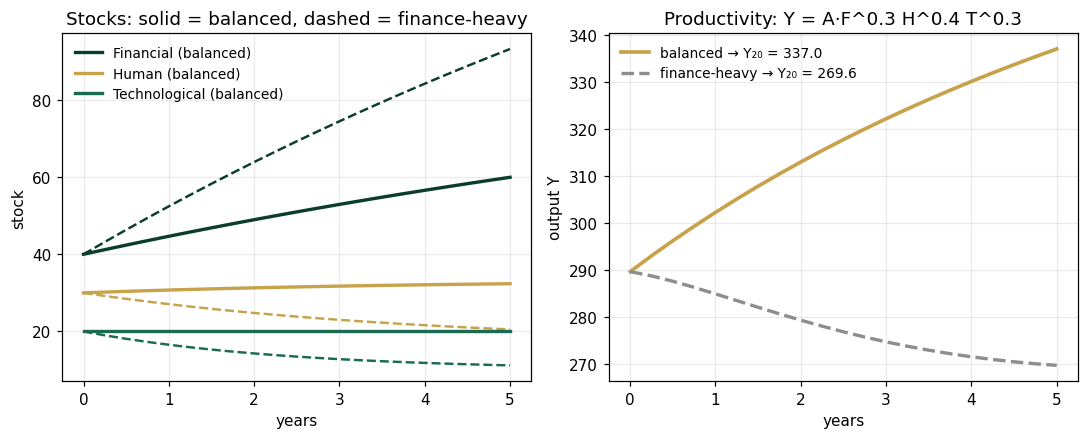

cumulative output gap (balanced − finance-heavy): 800.4275


In [2]:
ka, kb = path(I_A), path(I_B)
ya, yb = output(ka), output(kb)
t = np.arange(N+1)/4
fig, axes = plt.subplots(1, 2, figsize=(10,4.1))
for i,(nm,c) in enumerate(zip(["Financial","Human","Technological"],["#0B3D2E","#C8A24B","#1B6B52"])):
    axes[0].plot(t, ka[:,i], c=c, lw=2.2, label=nm+" (balanced)")
    axes[0].plot(t, kb[:,i], c=c, lw=1.6, ls="--")
axes[0].set(xlabel="years", ylabel="stock", title="Stocks: solid = balanced, dashed = finance-heavy")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)
axes[1].plot(t, ya, c="#C8A24B", lw=2.4, label=f"balanced → Y₂₀ = {ya[20]:.1f}")
axes[1].plot(t, yb, c="#8A8F8B", lw=2.2, ls="--", label=f"finance-heavy → Y₂₀ = {yb[20]:.1f}")
axes[1].set(xlabel="years", ylabel="output Y", title="Productivity: Y = A·F^0.3 H^0.4 T^0.3")
axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=.25)
plt.tight_layout(); plt.show()
print(f"cumulative output gap (balanced − finance-heavy): {ya[1:].sum()-yb[1:].sum():.4f}")

## Panel 2 — The asymmetry: one quarter down, ten quarters back
A 30% human-capital destruction at quarter 10 (a botched reorganization, a
talent exodus). Under unchanged investment, the stock needs **10 quarters** to
regain its pre-shock level — Depletion Reduces Adaptability, Asymmetrically
(Prop.), measured rather than asserted.

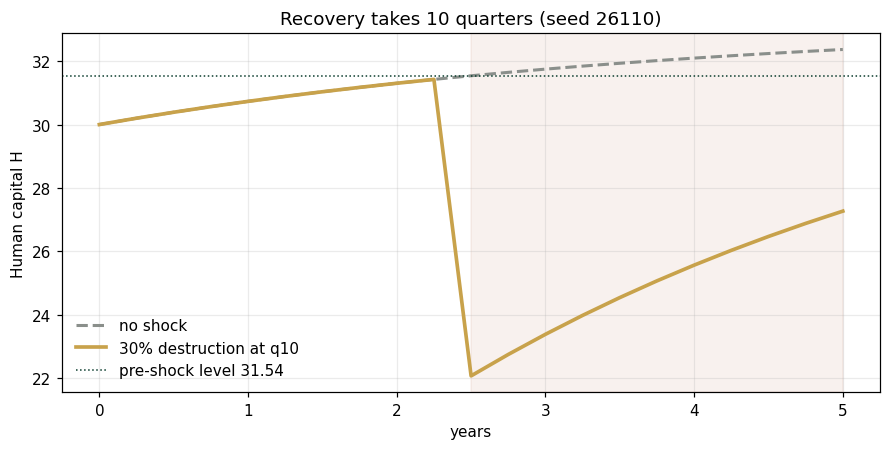

pre-shock H at q10: 31.5379   quarters below pre-shock after destruction: 10


In [3]:
base = path(I_A); sh = path(I_A, shock=(10,1,0.7))
pre, rec = recovery_quarters()
fig, ax = plt.subplots(figsize=(8.2,4.2))
ax.plot(t, base[:,1], c="#8A8F8B", lw=2, ls="--", label="no shock")
ax.plot(t, sh[:,1], c="#C8A24B", lw=2.4, label="30% destruction at q10")
ax.axhline(pre, c="#0B3D2E", lw=1, ls=":", label=f"pre-shock level {pre:.2f}")
ax.axvspan(2.5, 2.5+rec/4, color="#B0532F", alpha=.08)
ax.set(xlabel="years", ylabel="Human capital H", title=f"Recovery takes {rec} quarters (seed 26110)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"pre-shock H at q10: {pre:.4f}   quarters below pre-shock after destruction: {rec}")

## Panel 3 — Capital dependency, one edge
Human-capital investment is funded from financial capital: raise $I_H$ and $I_F$
falls by the same amount. The Capital Dependency Theorem in a one-line sweep —
each capital's best level is not independent of the others'.

In [4]:
print(f"{'I_H':>5s} {'I_F':>5s} {'Y at q20':>10s}")
for ih in [1.0, 2.0, 3.0, 4.0]:
    I = np.array([6.0-ih-1.0, ih, 1.0])
    y = output(path(I))[20]
    print(f"{ih:5.1f} {6.0-ih-1.0:5.1f} {y:10.4f}")

  I_H   I_F   Y at q20
  1.0   4.0   269.6156
  2.0   3.0   304.9242
  3.0   2.0   320.9460
  4.0   1.0   320.1353


## Validation — agrees with `DCT_V1_Ch10_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"F20_A":59.9435,"H20_A":32.3663,"T20_A":20.0,"Y20_A":337.0303,"Y20_B":269.6156,
 "cumY_gap_A_minus_B":800.4275,"H10_preshock":31.5379,"recovery_quarters":10}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:22s} {ref[k]}")
print("\nAll checkpoints agree — seed 26110.")

PASS  F20_A                  59.9435
PASS  H20_A                  32.3663
PASS  T20_A                  20.0
PASS  Y20_A                  337.0303
PASS  Y20_B                  269.6156
PASS  cumY_gap_A_minus_B     800.4275
PASS  H10_preshock           31.5379
PASS  recovery_quarters      10

All checkpoints agree — seed 26110.


**Next**: Exercises 10.9–10.12 (Part C) sweep δ, α, and the shock size; AXIOM-10's allocation bench makes the budget split draggable. Solutions: IM Ch. 10.